In [5]:
# %matplotlib inline
# import matplotlib.pyplot as plt


# import yaml
# import numpy as np

# import os
# import sys
# sys.path.append(f'{os.getcwd()}/irc_gym')

# from irc.manager import IRCManager

/home/lokesh/anaconda3/envs/IRC/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Train one agent for a single environment

In [ ]:
# defaults = {
#     'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
#     'agent.model._target_': 'irc.model.FuncBeliefModel',
# }
# manager = IRCManager(defaults=defaults)

## Compare between different environments

In [ ]:
# from auditoryforage.AF_env import AuditoryForaging

# # num_epochs = 400
# num_epochs = 40
# no_episodes = 1000
# lick_cost_list = [0]
# food_reward_list = [10.0, 25.0, 50.0, 75.0, 100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 1000.0]
# attention_cost_coeff_list = [.08]
# attention_cost_temp_list = [.25]
# penalty_cost_list = [0]
# iti_cost_list = [0]

# total_env_choices = 0

# hit_count_list = []
# miss_count_list = []
# false_alarm_list = []

# for lick_cost in lick_cost_list:
#     for food_reward in food_reward_list:
#         for attention_cost_coeff in attention_cost_coeff_list:
#             for attention_cost_temp in attention_cost_temp_list:
#                 for penalty_cost in penalty_cost_list:
#                     for iti_cost in iti_cost_list:
#                         env_param = [lick_cost, food_reward, attention_cost_coeff, attention_cost_temp, penalty_cost, iti_cost]
#                         env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5]}})
#                         agent = manager.train_agent(env_param, num_epochs=num_epochs)
#                         hit_count = 0
#                         miss_count = 0
#                         false_alarm_count = 0
#                         for episide_no in range(no_episodes):
#                             episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
#                             if episode['rewards'][-1] == food_reward:
#                                 hit_count += 1
#                             elif episode['states'][-1] > env.no_signal_nodes + 1:
#                                 miss_count += 1
#                             elif episode['states'][-1] == env.no_signal_nodes + 1:
#                                 false_alarm_count += 1
#                             else:
#                                 print("Error somewhere")
#                         hit_count_list.append(hit_count/no_episodes)
#                         miss_count_list.append(miss_count/no_episodes)
#                         false_alarm_list.append(false_alarm_count/no_episodes)
#                         total_env_choices += 1

In [ ]:
# from auditoryforage.utils import save_pickle_file

# folder_name = './store/comparison/'
# file_name = folder_name + 'diff_food_rewards.pkl'
# if not os.path.exists(folder_name):
#     os.makedirs(folder_name)

# detection_measures = {}
# input = {}
# output = {}
# input['food_reward_list'] = food_reward_list
# input['attention_cost_coeff_list'] = attention_cost_coeff_list
# input['attention_cost_temp_list'] = attention_cost_temp_list
# input['penalty_cost_list'] = penalty_cost_list
# input['iti_cost_list'] = iti_cost_list
# output['hit_count_list'] = hit_count_list
# output['miss_count_list'] = miss_count_list
# output['false_alarm_list'] = false_alarm_list
# detection_measures['input'] = input
# detection_measures['output'] = output
# save_pickle_file(detection_measures, file_name)

In [1]:
from auditoryforage.utils import open_pickle_file
folder_name = './store/comparison/'
file_name = folder_name + 'diff_food_rewards.pkl'
detection_measures = open_pickle_file(file_name)

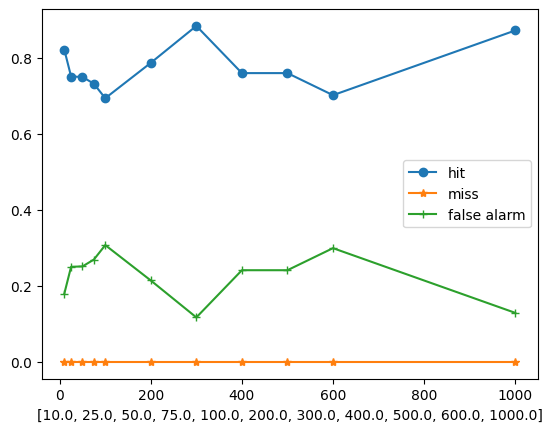

In [2]:
import matplotlib.pyplot as plt
food_reward_list = detection_measures['input']['food_reward_list']
hit_count_list = detection_measures['output']['hit_count_list']
miss_count_list = detection_measures['output']['miss_count_list']
false_alarm_list = detection_measures['output']['false_alarm_list']
plt.plot(food_reward_list, hit_count_list, 'o-')
plt.plot(food_reward_list, miss_count_list, '-*')
plt.plot(food_reward_list, false_alarm_list, '-+')
plt.legend(['hit', 'miss', 'false alarm'])
plt.xlabel(food_reward_list)
plt.show()